# 📊 Các biểu đồ Matplotlib & Seaborn thường dùng nhất

Bản rút gọn — chỉ gồm những loại biểu đồ **hay gặp nhất trong công việc thực tế** (báo cáo, phân tích dữ liệu, dashboard).

Dùng chung file `sample_sales_data.csv` (dữ liệu bán hàng mô phỏng) như notebook đầy đủ trước đó.

## 1. Import & đọc dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5.5)

df = pd.read_csv("sample_sales_data.csv", parse_dates=["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df.head()

,Date,Region,Category,Product,Quantity,Unit_Price,Discount_Percent,Sales_Amount,Profit,Customer_Age,Customer_Rating,Payment_Method,Channel,Month
0,2023-01-01,South,Furniture,Table,6,348.92,0,2929.70,766.72,30,4.5,Cash,Online,2023-01
1,2023-01-01,Central,Food,Dairy,9,24.59,5,294.19,60.87,29,5.0,Credit Card,In-Store,2023-01
2,2023-01-01,West,Furniture,Chair,6,262.08,15,1870.51,752.79,47,4.8,E-Wallet,Online,2023-01
3,2023-01-02,East,Clothing,T-Shirt,6,54.20,5,432.41,181.30,21,4.8,Cash,In-Store,2023-01
4,2023-01-02,North,Clothing,Shoes,8,57.40,0,642.74,266.93,39,3.9,E-Wallet,In-Store,2023-01


## 2. Matplotlib — 5 biểu đồ cơ bản hay dùng nhất

### 2.1 Line plot — xu hướng theo thời gian

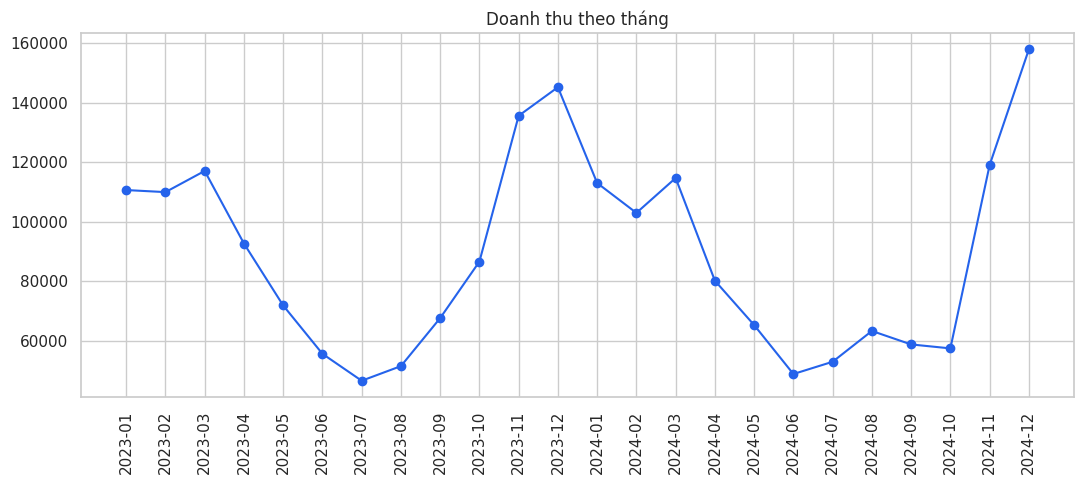

In [2]:
monthly = df.groupby("Month")["Sales_Amount"].sum()

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values, marker="o", color="#2563eb")
plt.title("Doanh thu theo tháng")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.2 Bar chart — so sánh giữa các nhóm

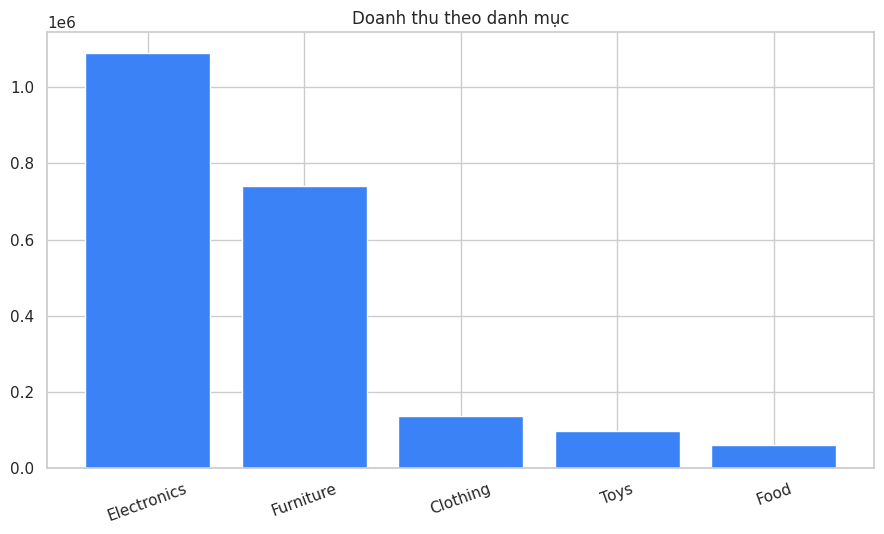

In [3]:
cat_sales = df.groupby("Category")["Sales_Amount"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(cat_sales.index, cat_sales.values, color="#3b82f6")
plt.title("Doanh thu theo danh mục")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 2.3 Scatter plot — quan hệ giữa 2 biến số

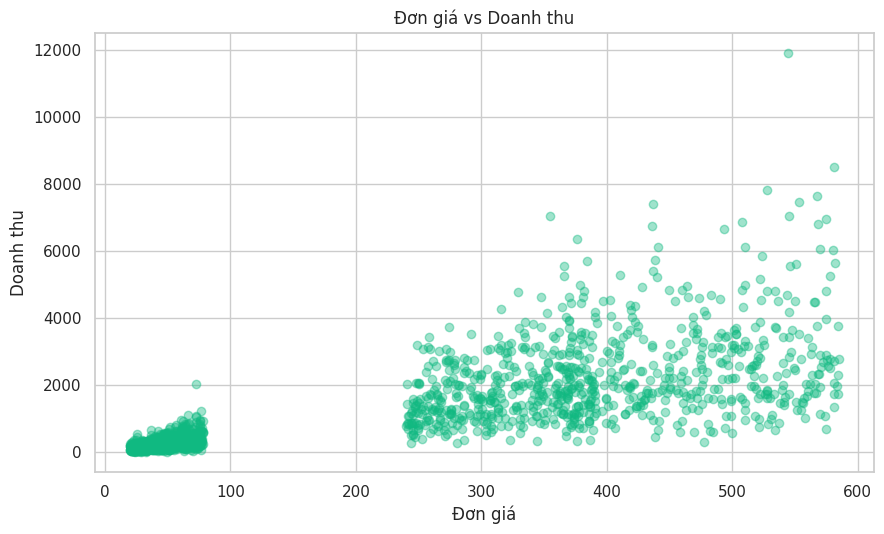

In [4]:
plt.figure()
plt.scatter(df["Unit_Price"], df["Sales_Amount"], alpha=0.4, color="#10b981")
plt.xlabel("Đơn giá")
plt.ylabel("Doanh thu")
plt.title("Đơn giá vs Doanh thu")
plt.tight_layout()
plt.show()

### 2.4 Histogram — phân phối dữ liệu

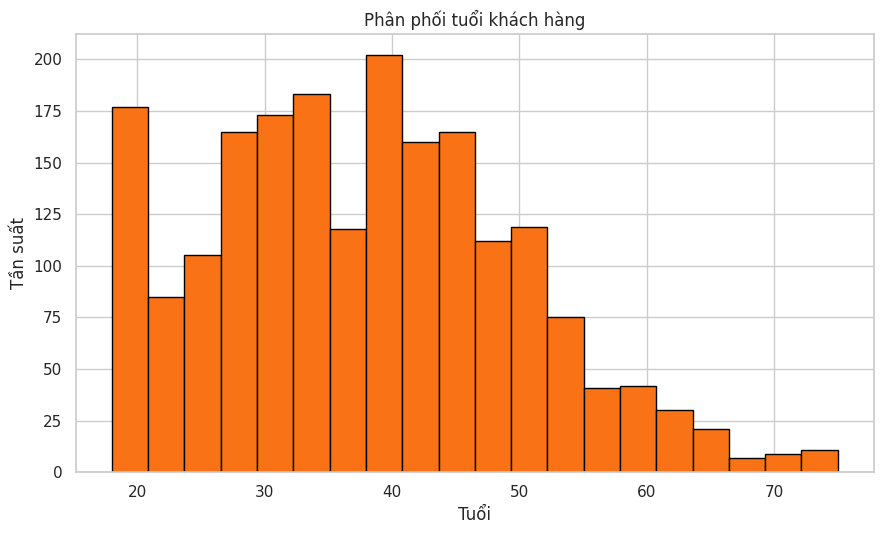

In [5]:
plt.figure()
plt.hist(df["Customer_Age"], bins=20, color="#f97316", edgecolor="black")
plt.title("Phân phối tuổi khách hàng")
plt.xlabel("Tuổi")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

### 2.5 Pie chart — tỉ trọng

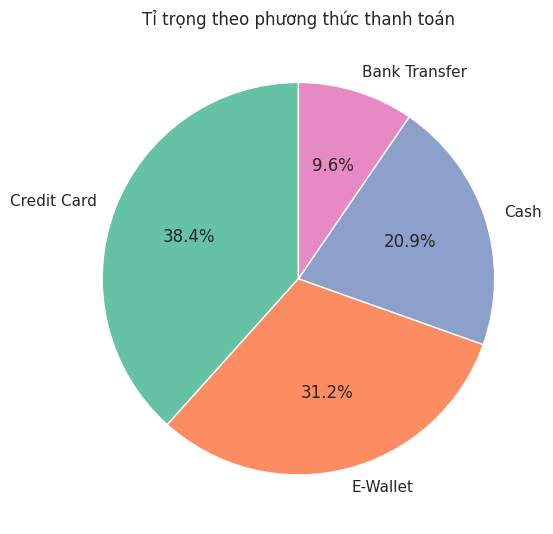

In [6]:
pay = df["Payment_Method"].value_counts()

plt.figure()
plt.pie(pay.values, labels=pay.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Set2", len(pay)))
plt.title("Tỉ trọng theo phương thức thanh toán")
plt.tight_layout()
plt.show()

## 3. Seaborn — các biểu đồ hay dùng nhất

### 3.1 `sns.scatterplot` — scatter có phân nhóm màu/kích thước

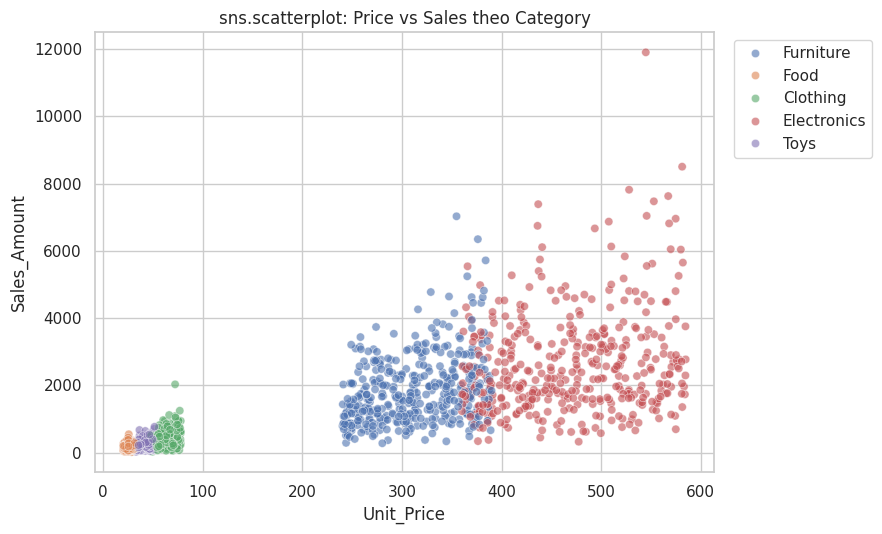

In [7]:
plt.figure()
sns.scatterplot(data=df, x="Unit_Price", y="Sales_Amount", hue="Category", alpha=0.6)
plt.title("sns.scatterplot: Price vs Sales theo Category")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3.2 `sns.lineplot` — line có khoảng tin cậy

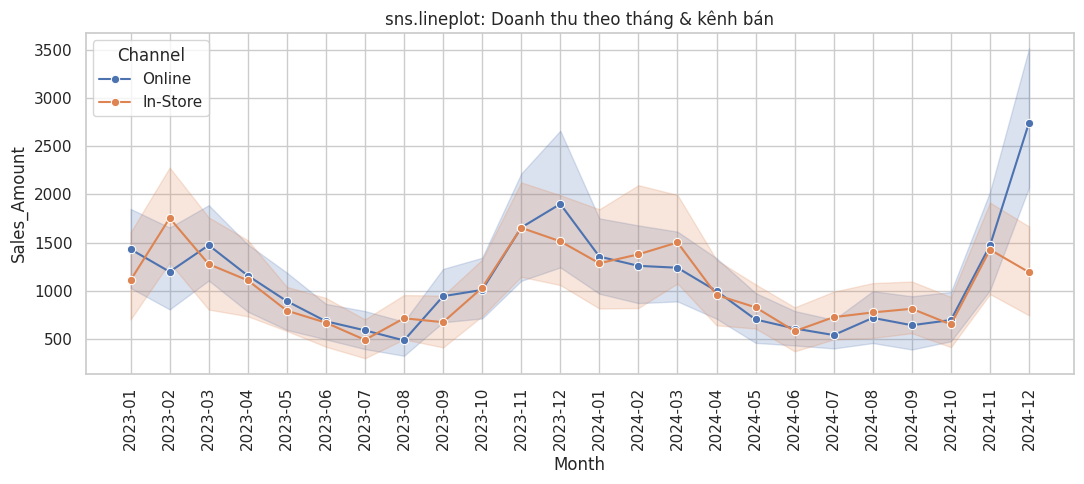

In [8]:
plt.figure(figsize=(11, 5))
sns.lineplot(data=df, x="Month", y="Sales_Amount", hue="Channel", marker="o")
plt.xticks(rotation=90)
plt.title("sns.lineplot: Doanh thu theo tháng & kênh bán")
plt.tight_layout()
plt.show()

### 3.3 `sns.barplot` — bar có sai số & phân nhóm

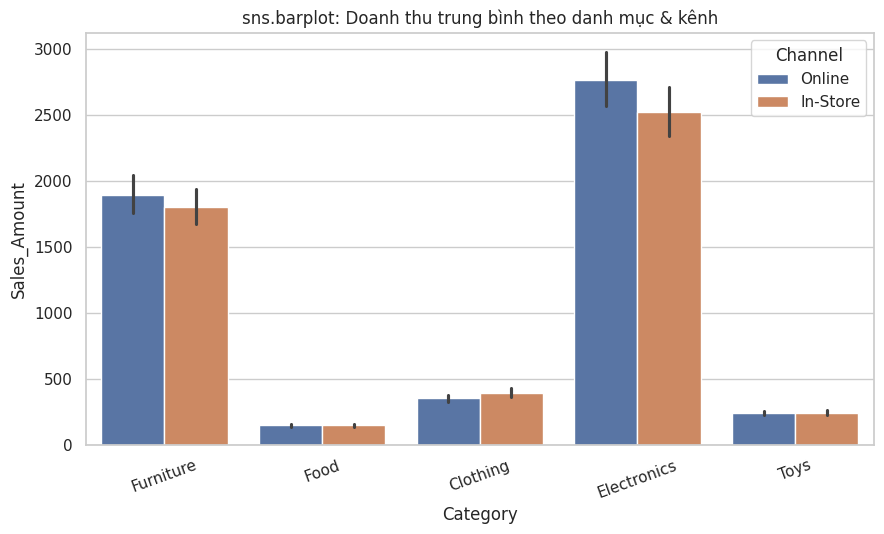

In [9]:
plt.figure()
sns.barplot(data=df, x="Category", y="Sales_Amount", hue="Channel")
plt.xticks(rotation=20)
plt.title("sns.barplot: Doanh thu trung bình theo danh mục & kênh")
plt.tight_layout()
plt.show()

### 3.4 `sns.countplot` — đếm số lượng theo nhóm

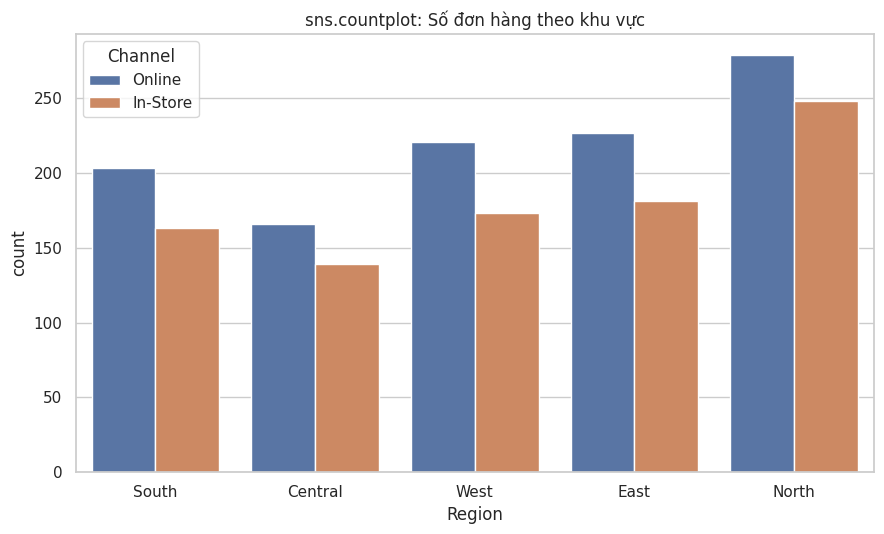

In [10]:
plt.figure()
sns.countplot(data=df, x="Region", hue="Channel")
plt.title("sns.countplot: Số đơn hàng theo khu vực")
plt.tight_layout()
plt.show()

### 3.5 `sns.histplot` — histogram nâng cao (có KDE)

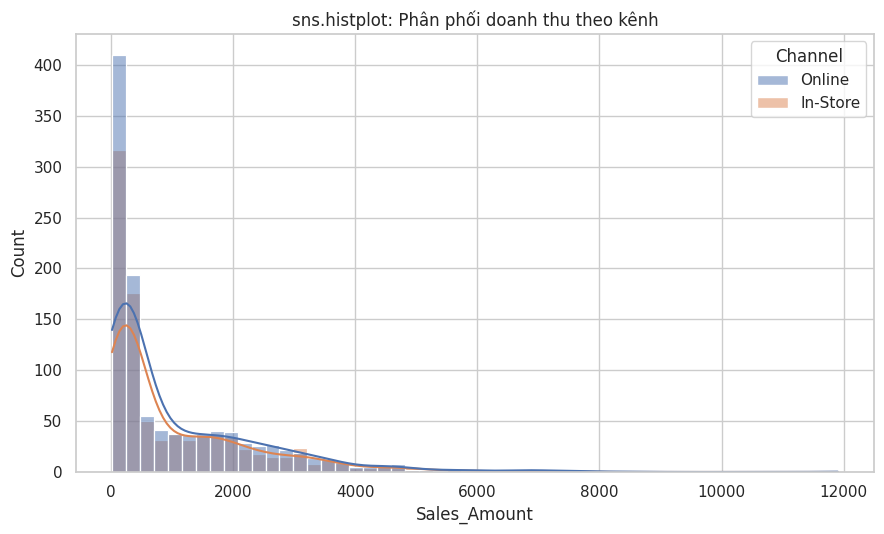

In [11]:
plt.figure()
sns.histplot(data=df, x="Sales_Amount", hue="Channel", kde=True, alpha=0.5)
plt.title("sns.histplot: Phân phối doanh thu theo kênh")
plt.tight_layout()
plt.show()

### 3.6 `sns.boxplot` — phân phối & outlier theo nhóm

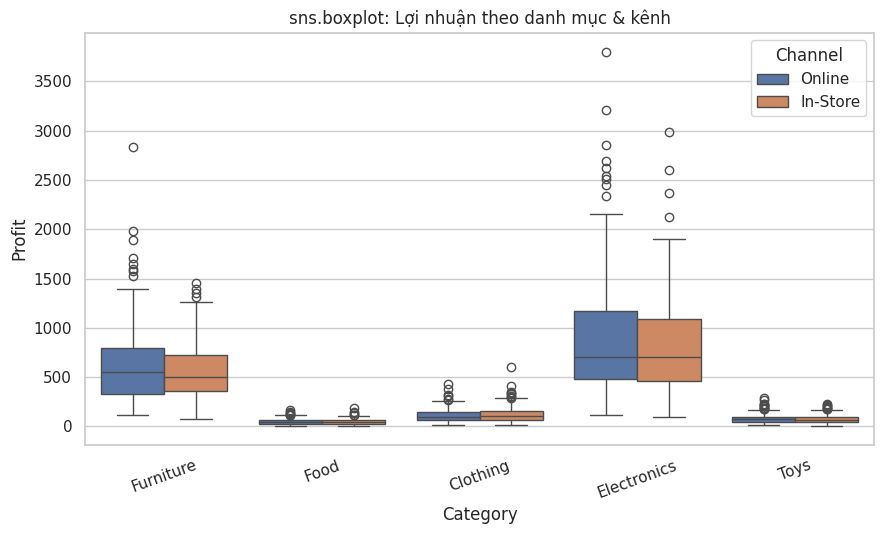

In [12]:
plt.figure()
sns.boxplot(data=df, x="Category", y="Profit", hue="Channel")
plt.xticks(rotation=20)
plt.title("sns.boxplot: Lợi nhuận theo danh mục & kênh")
plt.tight_layout()
plt.show()

### 3.7 `sns.heatmap` — ma trận tương quan

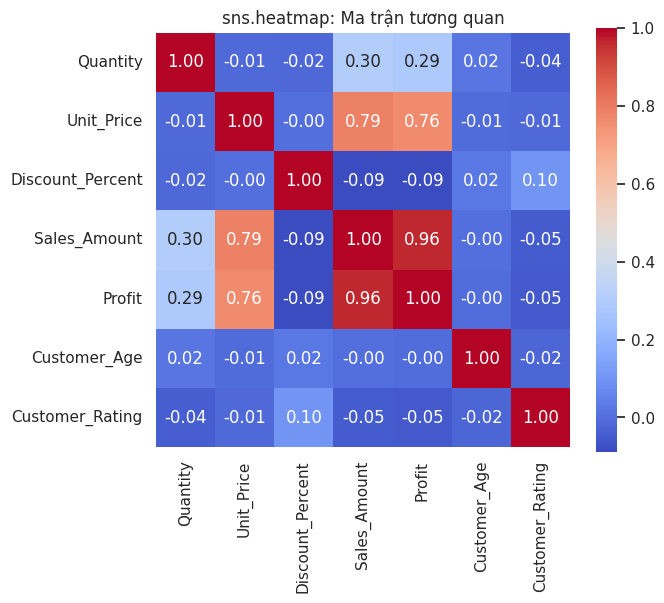

In [13]:
numeric_cols = ["Quantity", "Unit_Price", "Discount_Percent", "Sales_Amount", "Profit", "Customer_Age", "Customer_Rating"]

plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("sns.heatmap: Ma trận tương quan")
plt.tight_layout()
plt.show()

### 3.8 `sns.pairplot` — nhìn nhanh quan hệ đa biến

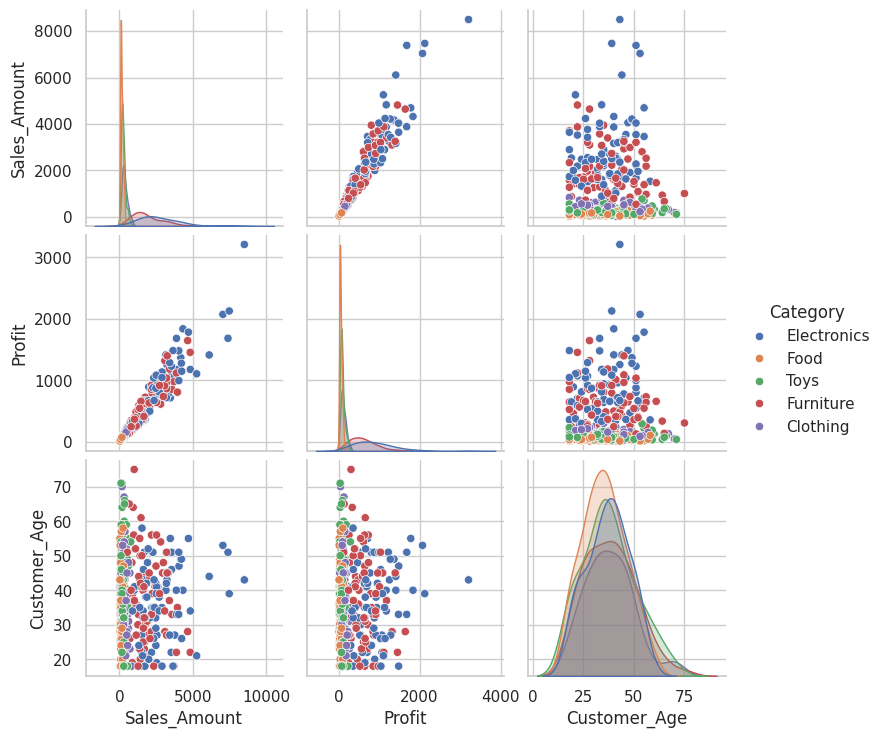

In [14]:
subset = df[["Sales_Amount", "Profit", "Customer_Age", "Category"]].sample(400, random_state=1)
sns.pairplot(subset, hue="Category", diag_kind="kde")
plt.show()